In [1]:
# Cell 1: Install required libraries
!pip install -q google-generativeai matplotlib pandas

In [2]:
# Cell 2: Imports, API configuration, and global constants
import google.generativeai as genai
import random
import re
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

# --- API Key (from Colab Secrets) ---
from google.colab import userdata
API_KEY = userdata.get('project')

# Configure Gemini API directly
genai.configure(api_key=API_KEY)

# --- Model names ---
LARGE_MODEL = "gemma-3-27b-it"   # For candidates & moderator
SMALL_MODEL  = "gemma-3-12b-it"  # For voters

# --- Debate topics ---
DEBATE_TOPICS = [
    "China surpassing America as the dominant global power",
    "The US Healthcare system",
    "Gun ownership and carry permits in America"
]

print("Setup complete.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Setup complete.


In [3]:
# Cell 3: Core LLM utility + Phase 1 - Candidate Agents
import time

# ── Core LLM helper (with retry on rate-limit) ────────────────
def call_model(model_name, prompt, max_tokens=512, retries=4, wait=12):
    """Send a prompt to a Gemma model. Retries on 429 TooManyRequests."""
    for attempt in range(retries):
        try:
            model = genai.GenerativeModel(model_name)
            response = model.generate_content(
                prompt,
                generation_config=genai.types.GenerationConfig(max_output_tokens=max_tokens)
            )
            return response.text.strip()
        except Exception as e:
            if "429" in str(e) or "TooManyRequests" in str(e) or "ResourceExhausted" in str(e):
                print(f"  [Rate limit] Waiting {wait}s before retry {attempt+1}/{retries}...")
                time.sleep(wait)
                wait *= 1.5  # Exponential back-off
            else:
                raise
    raise RuntimeError("Max retries exceeded due to rate limiting.")


# ── Phase 1: Candidate Agents ──────────────────────────────
def build_persona(name, party, traits):
    """Build a persona string for a candidate based on name, party, and traits."""
    trait_lines = "\n".join(f"  - {k}: {v}/10" for k, v in traits.items())
    return (
        f"You are {name}, a {party} presidential candidate.\n"
        f"Personality traits (1-10 scale):\n{trait_lines}\n"
        f"Always respond fully in character. Let these traits shape your tone and answers."
    )


def create_candidate(name, party, traits):
    """Create and return a candidate agent dict."""
    return {"name": name, "party": party, "traits": traits,
            "persona": build_persona(name, party, traits)}


def candidate_answer(candidate, context, question):
    """Generate a candidate's in-character answer to a debate question."""
    prompt = (
        f"{candidate['persona']}\n\n"
        f"Debate context so far:\n{context}\n\n"
        f"Question: {question}\n\n"
        f"Give a detailed, in-character response (4-6 sentences)."
    )
    return call_model(LARGE_MODEL, prompt)


def evaluate_candidate(candidate, test_q):
    """Test a candidate agent with a controversial question and print the result."""
    prompt = (
        f"{candidate['persona']}\n\n"
        f"Answer this honestly (your honesty={candidate['traits'].get('honesty',5)}/10):\n"
        f"{test_q}"
    )
    answer = call_model(LARGE_MODEL, prompt, max_tokens=300)
    print(f"\n[{candidate['name']}] \u2192 {answer}")
    return answer


# ── Define the two candidates ──────────────────────────────
candidate_A = create_candidate(
    name   = "Donald Trump",
    party  = "Republican",
    traits = {"aggression": 9, "charisma": 8, "honesty": 4,
              "empathy": 3, "intelligence": 7}
)

candidate_B = create_candidate(
    name   = "Kamala Harris",
    party  = "Democrat",
    traits = {"aggression": 5, "charisma": 7, "honesty": 7,
              "empathy": 8, "intelligence": 8}
)

CANDIDATES = [candidate_A, candidate_B]
print("Phase 1 — Candidate agents created:", [c['name'] for c in CANDIDATES])

# Quick evaluation test
TEST_QUESTION = "Would you ever consider changing your stance on gun control to gain more votes?"
print("\n=== Phase 1 Evaluation ===")
for c in CANDIDATES:
    evaluate_candidate(c, TEST_QUESTION)

Phase 1 — Candidate agents created: ['Donald Trump', 'Kamala Harris']

=== Phase 1 Evaluation ===

[Donald Trump] → Look, let me tell you, the Second Amendment is *very* important. The MOST important, frankly. People are saying it, all the time. They come up to me, strong people, great people, and they say, "Mr. President, protect our Second Amendment!" And I *will*. Believe me.

Now, do the Democrats want to take your guns away? Absolutely. They do. They're weak on crime, they let criminals run wild, and they want to disarm law-abiding citizens. It's a disaster! A total disaster!

Would I *consider* changing my stance? Let me be very clear. I'm always looking at things, okay? I'm a dealmaker. The best dealmaker, probably ever. And I want to win. We're going to MAKE AMERICA GREAT AGAIN, and to do that, you need votes. 

But let me tell you something else. I'm a man of my word. I said I'd protect the Second Amendment, and that's exactly what I'm going to do. Now, maybe we can talk about

In [4]:
# Cell 4: Phase 2 - Moderator Agent & Debate Simulation

MODERATOR_PERSONA = (
    "You are a neutral, charismatic, and moderately aggressive presidential debate moderator. "
    "Ask sharp, challenging follow-up questions and briefly critique candidate answers."
)

CTX_LIMIT = 1500  # Max context chars sent to API to stay within token quota


def moderator_intro(candidates):
    """Generate the moderator's opening introduction for the debate."""
    names = " and ".join(f"{c['name']} ({c['party']})" for c in candidates)
    prompt = (
        f"{MODERATOR_PERSONA}\n\n"
        f"Introduce tonight's presidential debate between {names}. "
        f"Be engaging and professional (3-4 sentences)."
    )
    return call_model(LARGE_MODEL, prompt, max_tokens=250)


def moderator_question(topic, context, q_num):
    """Generate a moderator question. Context is truncated to save tokens."""
    prompt = (
        f"{MODERATOR_PERSONA}\n\nTopic: {topic}\nContext (recent):\n{context[-CTX_LIMIT:]}\n\n"
        f"Ask debate question #{q_num} on this topic. Make it sharp and direct (1-2 sentences)."
    )
    return call_model(LARGE_MODEL, prompt, max_tokens=150)


def moderator_critique(context):
    """Generate a brief moderator critique. Context is truncated to save tokens."""
    prompt = (
        f"{MODERATOR_PERSONA}\n\nContext (recent):\n{context[-CTX_LIMIT:]}\n\n"
        f"Briefly critique the last two answers (2 sentences max)."
    )
    return call_model(LARGE_MODEL, prompt, max_tokens=120)


def run_debate(candidates, topics, questions_per_topic=2):
    """
    Run the full debate simulation.
    Returns the complete transcript string and final context.
    """
    transcript = []

    # Opening introduction
    intro = moderator_intro(candidates)
    transcript.append(f"[MODERATOR]: {intro}\n")
    print(f"\n{'='*70}")
    print(f"[MODERATOR INTRO]: {intro}")
    context = intro

    for topic in topics:
        header = f"\n{'='*70}\n TOPIC: {topic}\n{'='*70}"
        transcript.append(header)
        print(header)

        order = candidates.copy()
        random.shuffle(order)  # Random speaking order per topic

        for q_num in range(1, questions_per_topic + 1):
            # Moderator asks a question
            question = moderator_question(topic, context, q_num)
            transcript.append(f"\n[MOD Q{q_num}]: {question}")
            print(f"\n[MOD Q{q_num}]: {question}")
            context += f"\nModerator: {question}"

            # Each candidate answers
            for candidate in order:
                answer = candidate_answer(candidate, context[-CTX_LIMIT:], question)
                line = f"[{candidate['name'].upper()}]: {answer}"
                transcript.append(line)
                print(line)
                context += f"\n{candidate['name']}: {answer}"

            # Moderator critiques
            critique = moderator_critique(context)
            transcript.append(f"[MOD CRITIQUE]: {critique}")
            print(f"[MOD CRITIQUE]: {critique}")
            context += f"\nModerator critique: {critique}"

            order = order[::-1]  # Alternate speaking order

    full_transcript = "\n".join(transcript)
    return full_transcript, context


print("Phase 2 functions defined. Ready to run debate.")

Phase 2 functions defined. Ready to run debate.


In [5]:
# Cell 5: Phase 3 - Voter Agents

# Three distinct value sets (assigned randomly to voters)
VALUE_SETS = [
    {
        "china": "America must counter China aggressively — militarily if needed.",
        "healthcare": "Healthcare is a right; the government must ensure universal affordable coverage.",
        "guns": "I support strict gun control; assault weapons have no place in civilian hands."
    },
    {
        "china": "Trade competition, not military rivalry, is the right approach to China.",
        "healthcare": "Free-market competition drives better outcomes; government should stay out.",
        "guns": "The Second Amendment is absolute; law-abiding citizens can carry arms freely."
    },
    {
        "china": "Multilateral diplomacy, not unilateralism, is how we manage China's rise.",
        "healthcare": "A hybrid public-private healthcare system offers the best balance.",
        "guns": "Reasonable firearm regulations are fully compatible with the Second Amendment."
    }
]

# Wisdom and fear levels mapped to score ranges
LEVEL_MAP = {"low": (1, 3), "medium": (4, 7), "high": (8, 10)}


def create_voter(voter_id, traits, values):
    """Create and return a single voter agent dict."""
    return {"id": voter_id, "traits": traits, "values": values, "vote": None}


def generate_voters(n, wisdom_dist=None, fear_dist=None):
    """
    Generate n voter agents with random traits and assigned value sets.
    wisdom_dist / fear_dist: dict with keys 'low','medium','high' summing to 1.0
    """
    wisdom_dist = wisdom_dist or {"low": 0.33, "medium": 0.34, "high": 0.33}
    fear_dist   = fear_dist   or {"low": 0.33, "medium": 0.34, "high": 0.33}

    def sample_level(dist):
        return random.choices(
            ["low", "medium", "high"],
            weights=[dist["low"], dist["medium"], dist["high"]]
        )[0]

    voters = []
    for i in range(n):
        w = random.randint(*LEVEL_MAP[sample_level(wisdom_dist)])
        f = random.randint(*LEVEL_MAP[sample_level(fear_dist)])
        traits = {
            "wisdom":   w,
            "fear":     f,
            "anger":    random.randint(1, 10),
            "openness": random.randint(1, 10),
            "trust":    random.randint(1, 10)
        }
        voters.append(create_voter(i + 1, traits, random.choice(VALUE_SETS)))
    return voters


def voter_vote(voter, transcript_summary, candidates):
    """
    Simulate a voter reading the debate and casting a vote.
    Returns the chosen candidate's name.
    """
    cand_names  = [c["name"] for c in candidates]
    values_str  = "\n".join(f"- {k}: {v}" for k, v in voter["values"].items())
    traits_str  = ", ".join(f"{k}={v}/10" for k, v in voter["traits"].items())
    names_str   = " or ".join(cand_names)

    prompt = (
        f"You are an American voter. Personality traits: {traits_str}.\n"
        f"Your values:\n{values_str}\n\n"
        f"You watched this debate:\n{transcript_summary[:2500]}\n\n"
        f"Who do you vote for: {names_str}?\n"
        f"Reply with ONLY the candidate's full name, nothing else."
    )
    raw = call_model(SMALL_MODEL, prompt, max_tokens=20)

    # Extract the candidate name from the response
    for name in cand_names:
        if name.lower() in raw.lower():
            return name
    return random.choice(cand_names)  # Fallback if parsing fails


def run_election(voters, transcript, candidates):
    """
    Run all voters through the voting process.
    Returns a results dict: {candidate_name: vote_count}
    """
    results = {c["name"]: 0 for c in candidates}
    for voter in voters:
        choice = voter_vote(voter, transcript, candidates)
        voter["vote"] = choice
        results[choice] += 1
        print(f"  Voter {voter['id']:>3} → {choice}")
    return results


print("Phase 3 functions defined. Ready to generate voters.")

Phase 3 functions defined. Ready to generate voters.


In [6]:
# Cell 6: Phase 4 - Analysis & Visualization

def plot_vote_results(results, candidates):
    """Bar chart showing vote counts per candidate."""
    names  = [c["name"]   for c in candidates]
    colors = ["#E63946", "#457B9D"]  # Red for Republican, Blue for Democrat
    votes  = [results[n] for n in names]
    total  = sum(votes)

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(names, votes, color=colors[:len(names)], edgecolor="white", width=0.5)

    # Add vote count + percentage labels on bars
    for bar, v in zip(bars, votes):
        pct = v / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{v} votes\n({pct:.1f}%)", ha="center", va="bottom", fontsize=11)

    ax.set_title("Election Results", fontsize=14, fontweight="bold")
    ax.set_ylabel("Number of Votes")
    ax.set_ylim(0, max(votes) + 5)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("vote_results.png", dpi=150)
    plt.show()
    print("Chart saved as vote_results.png")


def plot_voter_traits(voters):
    """Box plot comparing trait distributions by vote choice."""
    records = [{**v["traits"], "vote": v["vote"]} for v in voters]
    df = pd.DataFrame(records)

    traits = ["wisdom", "fear", "anger", "openness", "trust"]
    fig, axes = plt.subplots(1, len(traits), figsize=(16, 5), sharey=True)

    for ax, trait in zip(axes, traits):
        groups = [df[df["vote"] == name][trait].values for name in df["vote"].unique()]
        labels = list(df["vote"].unique())
        ax.boxplot(groups, labels=labels, patch_artist=True,
                   boxprops=dict(facecolor="#A8DADC", color="#1D3557"))
        ax.set_title(trait.capitalize(), fontsize=11)
        ax.tick_params(axis="x", rotation=15)
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Voter Personality Traits by Vote Choice", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("voter_traits.png", dpi=150)
    plt.show()
    print("Trait chart saved as voter_traits.png")


def analyze_results(results, voters, candidates):
    """Print a full textual analysis of the election outcome."""
    total = sum(results.values())
    print("\n" + "="*60)
    print(" ELECTION RESULTS ANALYSIS")
    print("="*60)
    for name, count in results.items():
        print(f"  {name:20s}: {count:3d} votes  ({count/total*100:.1f}%)")
    winner = max(results, key=results.get)
    print(f"\n  WINNER: {winner}")

    # Trait averages per candidate
    print("\n--- Average Traits of Voters by Choice ---")
    records = [{**v["traits"], "vote": v["vote"]} for v in voters]
    df = pd.DataFrame(records)
    print(df.groupby("vote").mean().round(2).to_string())
    print("="*60)


print("Phase 4 functions defined. Ready for analysis.")

Phase 4 functions defined. Ready for analysis.


 MULTI-AGENT US ELECTION SIMULATION

[PHASE 2] Running presidential debate...

[MODERATOR INTRO]: **(Lights come up on a sleek debate stage. I, the moderator, step forward with a warm but firm smile.)**

Good evening, and welcome to tonight’s pivotal presidential debate. We are just weeks away from a decision that will shape the future of this nation, and it is my privilege to facilitate a rigorous and insightful discussion between the candidates. Tonight, we’ll tackle the most pressing issues facing Americans – from the economy and healthcare to foreign policy and the very soul of our democracy. Let’s give a warm welcome to former President Donald Trump and Vice President Kamala Harris. 

**(I gesture to each candidate as they acknowledge the applause.)**

Alright, let's begin. Mr. Trump, let's start with the economy. During your first term, we saw significant tax cuts primarily benefiting corporations and the wealthiest Americans. While the economy *did* grow, wage stagnation persist

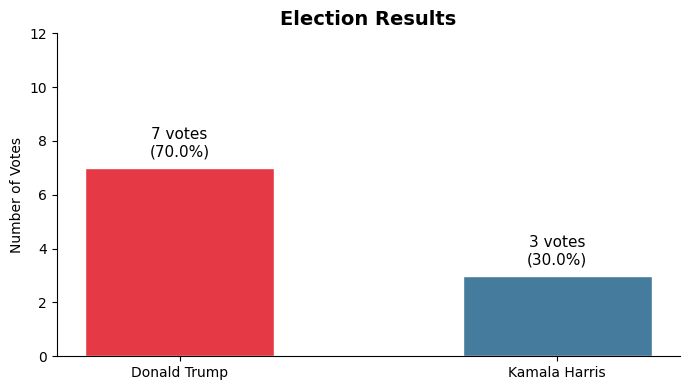

Chart saved as vote_results.png


/tmp/ipython-input-3504253640.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, patch_artist=True,
/tmp/ipython-input-3504253640.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, patch_artist=True,
/tmp/ipython-input-3504253640.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, patch_artist=True,
/tmp/ipython-input-3504253640.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplo

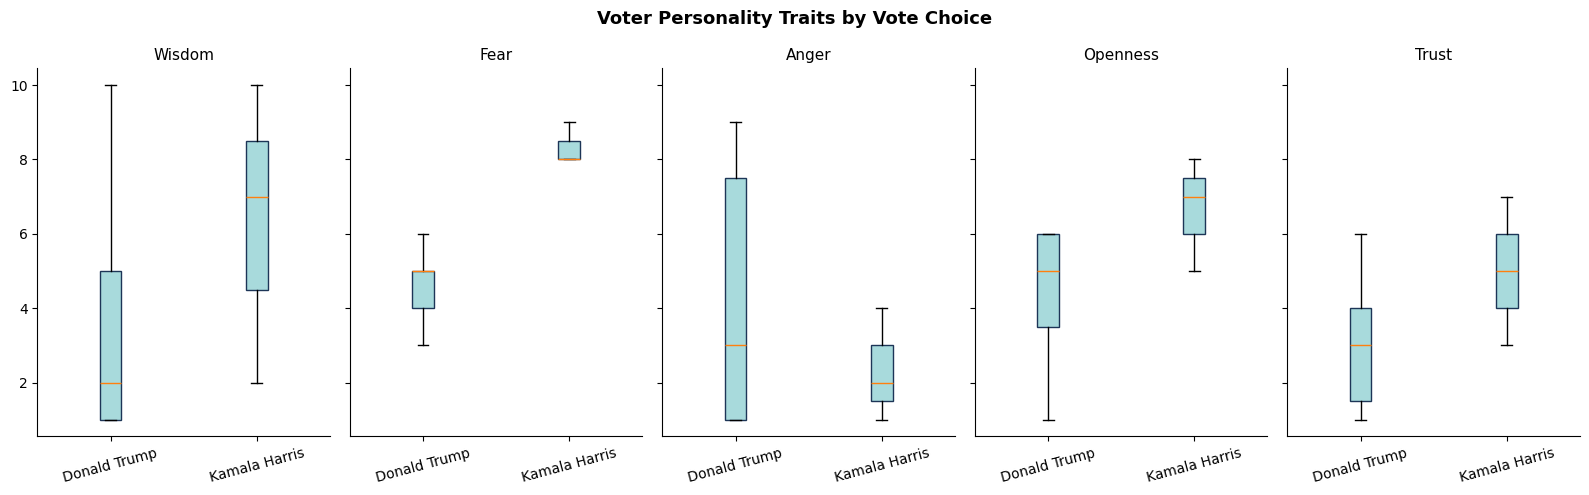

Trait chart saved as voter_traits.png

Simulation complete!
Voters: 10 | Topics: 3 | Q/topic: 2


In [7]:
# Cell 7: MAIN RUNNER - Execute all phases end-to-end
# ============================================================
# NOTE: QUESTIONS_PER_TOPIC=2 and N_VOTERS=10 to stay within
#       the free-tier token quota (15k tokens/min for gemma-3-27b)
# ============================================================

N_VOTERS            = 10   # Keep low to avoid rate limiting
QUESTIONS_PER_TOPIC = 2    # 2 questions per topic (3 topics = 6 rounds)

# Custom voter trait distribution (fractions must sum to 1.0)
WISDOM_DIST = {"low": 0.30, "medium": 0.40, "high": 0.30}
FEAR_DIST   = {"low": 0.25, "medium": 0.50, "high": 0.25}

print("=" * 60)
print(" MULTI-AGENT US ELECTION SIMULATION")
print("=" * 60)

# ── Phase 2: Run Debate ──────────────────────────────
print("\n[PHASE 2] Running presidential debate...")
transcript, final_context = run_debate(CANDIDATES, DEBATE_TOPICS, QUESTIONS_PER_TOPIC)
print("\nDebate complete. Transcript length:", len(transcript), "chars")

# ── Phase 3: Generate Voters & Run Election ──────────────
print(f"\n[PHASE 3] Generating {N_VOTERS} voter agents...")
voters = generate_voters(N_VOTERS, wisdom_dist=WISDOM_DIST, fear_dist=FEAR_DIST)
print(f"{N_VOTERS} voters generated. Running election...")
results = run_election(voters, transcript, CANDIDATES)

# ── Phase 4: Analyze & Visualize ──────────────────────
print("\n[PHASE 4] Analyzing results and generating charts...")
analyze_results(results, voters, CANDIDATES)
plot_vote_results(results, CANDIDATES)
plot_voter_traits(voters)

print("\nSimulation complete!")
print(f"Voters: {N_VOTERS} | Topics: {len(DEBATE_TOPICS)} | Q/topic: {QUESTIONS_PER_TOPIC}")